# Thesis: Reclaimed Timber in Deep Generative Design
**Notebook ID:** c23_design_space_optimizer     
**Author:** Jasper Cluistra   
**Last Updated:** 2026-03-19
### Design space optimization script
**Goal:** Optimize the structure by iterating over structural performance, circular performance, and total cost.
**Inputs:**
*   Search space definition
*   Trained surrogate model
*   Material input dataset

**Outputs:**
*   Optimized design candidates
*   Ranked solution set

# INPUT

In [ ]:
import importlib
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import config
from workflows import c23_stage_geometry as stage_geometry
from workflows import c25_stage_feasibility as stage_feasibility
from workflows import c26_stage_cost_matrix as stage_cost
from workflows import c27_stage_milp as stage_milp
from workflows import c28_stage_fitness as stage_fitness
from workflows import c28_stage_normalization_bounds as stage_bounds

importlib.reload(stage_geometry)
importlib.reload(stage_feasibility)
importlib.reload(stage_cost)
importlib.reload(stage_milp)
importlib.reload(stage_fitness)
importlib.reload(stage_bounds)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# One-time: search space + stock dataset
json_path = config.DATA_IO_PATH / "search_space.json"
with open(json_path, "r", encoding="utf-8") as f:
    optimizer_search_space = json.load(f)

testing = False
if testing:
    file_path = config.TIMBER_STOCK_PATH / "complete_timber_small.csv"
else:
    file_path = config.TIMBER_STOCK_PATH / "complete_timber.csv"

read_attempts = [
    {"sep": ",", "encoding": "utf-8"},
    {"sep": ";", "encoding": "utf-8"},
    {"sep": ",", "encoding": "latin1"},
    {"sep": ";", "encoding": "latin1"},
]

df_input_stock = None
for opts in read_attempts:
    try:
        df_try = pd.read_csv(file_path, **opts)
        if df_try.shape[1] > 1:
            df_input_stock = df_try
            print(f"Loaded stock with sep='{opts['sep']}' and encoding='{opts['encoding']}'")
            break
    except Exception:
        pass

if df_input_stock is None:
    raise ValueError("Could not parse stock CSV with tested delimiter/encoding combinations.")

df_input_stock.columns = df_input_stock.columns.str.strip()

# One-time: surrogate bundle cache
MODEL_PREFIX = None  # kept for backward compatibility with later notebook cells
MODEL_PREFIX_COMPLEX = "ID20260418_215020_LR0.0005_EP100_R0.99_F6"
MODEL_PREFIX_SIMPLE = "ID20260421_193347_LR0.0005_EP150_R0.99_F5"
SURROGATE_EDGE_FEATURE_MODE = "area_length"
active_prefix_for_bundle = MODEL_PREFIX_COMPLEX if SURROGATE_EDGE_FEATURE_MODE == "area_length" else MODEL_PREFIX_SIMPLE

SURROGATE_BUNDLE, SURROGATE_BUNDLE_ERROR = stage_feasibility.feasibility_check.prepare_surrogate_bundle(
    model_prefix=active_prefix_for_bundle,
)

if SURROGATE_BUNDLE is not None:
    print("Surrogate bundle loaded and cached for GA session.")
else:
    print("Surrogate bundle unavailable; GA uses synthetic force fallback.")
    print(f"Load reason: {SURROGATE_BUNDLE_ERROR}")

# GA configuration (balanced defaults)
GA_CONFIG = {
    "population_size": 30,
    "generations": 30,
    "elite_count": 2,
    "tournament_k": 3,
    "crossover_rate": 0.85,
    "mutation_rate": 0.25,
    "mutation_scale": 0.10,
    "utilization_threshold": 1.25,
    "surrogate_edge_feature_mode": SURROGATE_EDGE_FEATURE_MODE,
    "fitness_weights": {"omega_1": 1.0, "omega_2": 1.0, "omega_3": 1.0},
    "penalty_fitness": 1e6,
    "max_retries_per_individual": 2,
    "new_stock_max_uses": 1,
    "use_one_time_bounds": True, 
    "bounds_probe_attempts": 8,
}

# Fixed normalization constants for whole GA run (can be overwritten by one-time bounds)
FIXED_NORMALIZATION_CONSTANTS = stage_fitness.get_default_normalization_constants()

print(f"Search space variables: {len(optimizer_search_space)}")
print(f"Stock elements: {len(df_input_stock)}")
print(f"Fixed normalization constants (initial): {FIXED_NORMALIZATION_CONSTANTS}")
display(df_input_stock.head(3))

System loaded successfully.

Code is running locally from: thesis_generative_timber
Data connected to OneDrive: 2.2 - 2.4

GH data directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\01_grasshopper_data
Raw data directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\02_raw_data
Export directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports

GRID: 2x2, EDGE_LENGTH: 3.0, LAYER_HEIGHT: 1.5, DIVISIONS: 8, NUM_SAMPLES: 20000

IMPACT_FACTOR_A1_A3: 0.25, IMPACT_FACTOR_RECOVERED_C1: 0.0085, "ENERGY_PREP_SAW_A5: 0.02, ENERGY_OFFCUT_FACTOR_C3_C4: 0.276, SCARCITY_PENALTY: 0

parameters loaded from c:\Users\Jasper\Documents\PyRepo\thesis_generative_timber\c00_headquarter_params.py


c:\Users\Jasper\Documents\PyEnvs\thesis_home_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded stock with sep=';' and encoding='utf-8'
Loaded surrogate prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6
Device: cuda
Model: ID20260418_215020_LR0.0005_EP100_R0.99_surrogate_model.pt
Model variant: v1
Surrogate bundle loaded and cached for GA session.
Search space variables: 18
Stock elements: 480
Fixed normalization constants (initial): {'C_max': 8.0, 'R_max': 100.0, 'W_max': 0.4}


,Member_ID,State,Length,Depth,Width,f_mk,f_tk,E_modulus_eff,E_modulus_005,f_vk,f_c0k,k_density,mean_density,Origin_Country,Transport_Dist,EmissionFactor
0,NS_00000,0,1500.0,100.0,38.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Germany,279.66,0.1751
1,NS_00001,0,1500.0,100.0,50.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,57.45,0.1761
2,NS_00002,0,1500.0,100.0,63.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,47.51,0.1701


# OPTIMIZER

## GA Strategy & Search Space

This notebook implements a **custom Genetic Algorithm (GA)** to optimize timber structures by iterating over the entire design workflow (c24-c27).

### What the GA is Doing

**Goal:** Minimize embodied carbon while maximizing reuse of reclaimed timber and maintaining structural adequacy.

**Search Strategy:**
1. **Initialization**: Generate 30 random candidate designs by sampling 18 design variables from the search space
2. **Evaluation**: For each design, run the full pipeline:
   - Generate geometry (vertices/edges) from design parameters
   - Predict member forces using GNN surrogate model
   - Compute utilization matrix for all members
   - Build cost matrix (carbon footprint for each slot-stock pairing)
   - Solve MILP optimization to find optimal timber assignment
   - Calculate multi-objective fitness (cost + reuse rate + structural check)
3. **Selection & Reproduction**: Retain best designs (elitism), breed new candidates through:
   - **Tournament selection**: Pick 3 random individuals, keep fittest
   - **Crossover**: Blend two parent designs (50/50 mix for continuous vars, random choice for discrete)
   - **Mutation**: Randomly perturb ~25% of parameters in each child design
4. **Iteration**: Repeat evaluation + selection for 30 generations

**Convergence**: By generation 30, the algorithm converges to high-fitness designs (low cost, high reuse).

### How the GA Moves Points

The **18 design variables** control the geometry by modifying node positions and proportions:

| Variable Type | Count | Controls | Movement Mechanism |
|---|---|---|---|
| **Vertex shifts** (X, Y, Z) | 9 | Position of nodes | Continuous mutation (Gaussian perturbation) + crossover (linear blend) |
| **Bilinear parameters** (U, V) | 6 | Proportional grid scaling | Continuous mutation (scaled by search space span) + crossover |
| **Discrete parameters** | 3 | Topology/feature selection | Random swap between categorical options (e.g., span type) |

**Mutation Details:**
- Each parameter has ~25% chance to mutate per generation
- **Continuous variables** (vertex shifts, bilinear params): Add Gaussian noise (σ = 10% of search range), then clip to bounds
  - Example: If Y-shift range is [−0.5m, +0.5m], mutation adds noise up to ±0.05m
  - This gradually explores neighborhood around current solution
- **Discrete variables**: Randomly swap to alternative option (e.g., span_type: "simple" → "complex")

**Crossover Details:**
- Each parent contributes to child with 50% probability (arithmetic mean for continuous, random pick for discrete)
- Example: If Parent A has Y-shift=−0.3m and Parent B has Y-shift=+0.2m, child could be Y-shift=−0.05m
- This explores design space between successful parents

**Result**: Population gradually shifts toward low-cost, high-reuse designs. Node positions are refined through many small mutations; radically different topologies emerge through crossover of diverse parents.


In [2]:
# Custom GA operators (mixed discrete/continuous parameter dicts)
def _clip_continuous(value, bounds):
    return float(np.clip(value, float(bounds["min"]), float(bounds["max"])))


def _mutate_param(key, value, rules, mutation_scale=0.1):
    if rules["type"] == "continuous":
        span = float(rules["max"]) - float(rules["min"])
        sigma = max(span * float(mutation_scale), 1e-9)
        mutated = float(value) + float(np.random.normal(0.0, sigma))
        return _clip_continuous(mutated, rules)

    options = list(rules["options"])
    if len(options) <= 1:
        return value
    candidates = [opt for opt in options if opt != value]
    return random.choice(candidates)


def random_individual(search_space):
    return stage_geometry.sample_random_design(search_space)


def tournament_selection(population, fitnesses, k=3):
    idx = random.sample(range(len(population)), k=min(int(k), len(population)))
    best_idx = min(idx, key=lambda i: fitnesses[i])
    return population[best_idx].copy()


def crossover(parent_a, parent_b, search_space):
    child = {}
    for key, rules in search_space.items():
        a = parent_a[key]
        b = parent_b[key]

        if rules["type"] == "continuous":
            alpha = random.random()
            value = alpha * float(a) + (1.0 - alpha) * float(b)
            child[key] = _clip_continuous(value, rules)
        else:
            child[key] = random.choice([a, b])
    return child


def mutate(individual, search_space, mutation_rate=0.2, mutation_scale=0.1):
    out = individual.copy()
    for key, rules in search_space.items():
        if random.random() < float(mutation_rate):
            out[key] = _mutate_param(
                key=key,
                value=out[key],
                rules=rules,
                mutation_scale=float(mutation_scale),
            )
    return out


def initialize_population(search_space, size):
    return [random_individual(search_space) for _ in range(int(size))]


print("GA operators ready.")
print(f"Population size (default): {GA_CONFIG['population_size']}")

GA operators ready.
Population size (default): 30


### GA Operators: Selection, Crossover & Mutation

**Tournament Selection**
- Randomly picks `k=3` individuals from population
- Selects the one with best (lowest) fitness
- Biased toward better solutions but preserves diversity (weaker candidates still have chance if picked)

**Crossover (Point Blending)**
- Takes two parent designs (parameter dicts)
- For each of the 18 design variables:
  - **Continuous** (vertex shifts, bilinear params): Child value = α × Parent_A + (1−α) × Parent_B, where α ∈ [0,1] random
  - **Discrete** (categorical options): Child randomly chooses Parent_A's or Parent_B's option
- Result: New candidate that inherits traits from both parents (explores design space between them)

**Mutation (Parameter Perturbation)**
- For each of 18 design variables, ~25% chance to mutate:
  - **Continuous**: Add Gaussian noise scaled to 10% of search range, then clip to bounds
    - Allows fine-tuning within bounds; prevents extreme jumps
  - **Discrete**: Swap to random alternative option from list
- Result: Introduces variation; prevents population from converging to local optimum

**Elitism**
- Keep top 2 designs from previous generation unchanged in next population
- Ensures best solutions never disappear
- Accelerates convergence to high-fitness region


### Why Points Move in Certain Directions: The Fitness Feedback Loop

**The key insight:** The GA doesn't have explicit rules like "move vertex X higher" or "increase span length." Instead, direction emerges from **fitness-driven selection**.

**How it works:**

1. **Mutation is Blind (Random Direction)**
   - Each mutation adds Gaussian noise with equal probability in all directions
   - Parent design has Y_shift = +0.2m → mutation might move it to +0.3m (up) or +0.1m (down) with ~equal probability
   - Discrete variables randomly swap between options with no bias

2. **Selection Filters by Fitness (Creates Direction)**
   - After all 30 individuals are evaluated, compare their fitness scores
   - **Best designs reproduce** (kept in population via elitism, selected for crossover)
   - **Worst designs die out** (discarded when selecting tournament winners)
   - This is the crucial feedback: if designs with higher Y_shift tend to produce lower embodied carbon, they survive; if lower Y_shift produces better fitness, those survive instead

3. **Crossover Exploits Discovered Patterns (Reinforces Direction)**
   - When two high-fitness parents both have Y_shift ≈ +0.25m, crossover tends to keep that range
   - Their offspring inherits Y_shift near +0.25m, with small mutation perturbations
   - Over generations, the population converges around parameter values that **correlate with low fitness**

4. **Result: Emergent Direction**
   - No central planner decides "move Y-shift higher"
   - But if geometry designs with higher Y-shift happen to reduce member utilization → lower cost → better fitness → those designs get selected
   - Population gradually drifts upward in Y-shift across generations
   - Different parameters drift different directions based on their correlation with cost, reuse rate, waste volume

**Example Trajectory:**
```
Generation 1: Population Y_shift range = [−0.5, +0.5] (random)
              → Evaluate all 30 designs
              → Observe: designs with Y_shift > 0 have better fitness (lower carbon)

Generation 2: Tournament selection favors Y_shift > 0 designs
              → Best designs reproduce
              → New population Y_shift range ≈ [−0.2, +0.4]
              → Mutation adds noise (still random direction)
              → But population mean drifts upward

Generation 30: Convergence
              → Best designs all cluster around Y_shift ≈ +0.3 to +0.35m
              → Small mutations explore ±0.05m neighborhood
              → But rarely drift back downward (selection pressure)
```

**Key Takeaway:** The GA is an **adaptive random search** guided by fitness. Mutation explores randomly, but selection acts like a compass pointing toward low-carbon, high-reuse designs. Emergent movement directions reflect the underlying **design problem landscape**—which parameter combinations actually lead to good structures.


## 24_ Geometry

In [3]:
# Optional one-sample geometry sanity check before GA run
geometry_out = stage_geometry.run_random_geometry_stage(
    optimizer_search_space=optimizer_search_space,
    sample_id=0,
)

df_vertices_example = geometry_out["df_vertices"]
df_edges_example = geometry_out["df_edges"]
df_geometry_overview_example = geometry_out["df_geometry_overview"]

print(
    f"Example geometry: {len(df_vertices_example)} nodes, "
    f"{len(df_edges_example)} members"
 )
display(df_geometry_overview_example[["edge_id", "V1", "V2", "length_m"]].head(5))

Example geometry: 13 nodes, 32 members


,edge_id,V1,V2,length_m
0,e0,0,1,3.750
1,e1,0,3,1.875
2,e2,1,2,2.250
3,e3,1,4,4.193
4,e4,2,5,2.625


## 24-27 Iteration

### GA Evaluation Pipeline: How Designs Are Scored

Each design candidate in the population is evaluated through a 5-stage pipeline to compute its fitness:

| Stage | Input | Output | Purpose |
|---|---|---|---|
| **c23 Geometry** | Design parameters (18 variables) | Vertex coords, member connectivity | Convert abstract design vars to 3D truss structure |
| **c25 Structural** | Geometry + stock data | Member forces, utilization matrix | Use GNN model to predict forces; check if members can handle loads |
| **c26 Cost Matrix** | Utilization matrix + stock catalog | Carbon cost for each (slot, stock) pair | Build optimization problem: which reclaimed/new timber for each member? |
| **c27 MILP** | Cost matrix | Optimal assignment + total cost | Solve integer program: minimize embodied carbon via timber selection |
| **c24 Fitness** | MILP results + design metrics | Normalized multi-objective score | Combine cost, reuse %, waste volume into single fitness value |

**Fitness Calculation:**
```
fitness = weighted_sum(
    cost_normalized = total_carbon / 8.0,           # Normalize to reference 8 kg CO2e
    reuse_normalized = (100 - reuse_rate) / 100,   # Prefer high reuse (normalize as 0-1)
    waste_normalized = waste_volume / 0.4            # Normalize to reference 0.4 m³
)
```
*(Weights depend on `weight_strategy`; default is "cost-dominant")*

**Failure Handling:**
- If MILP solver fails (infeasible timber assignment): Assign penalty fitness = 1,000,000 (very bad)
- If geometry generation or structural check errors: Penalty fitness applied, GA continues
- Low-fitness individuals are less likely to be selected for reproduction → pressure toward feasible, efficient designs

**Result:** After 30 generations, the best design in population is returned with its geometry, timber assignment, and performance metrics.


In [6]:
def _resolve_weight_config(config_dict):
    weights = config_dict.get("fitness_weights")
    if isinstance(weights, dict):
        return {
            "omega_1": float(weights.get("omega_1", 1.0)),
            "omega_2": float(weights.get("omega_2", 1.0)),
            "omega_3": float(weights.get("omega_3", 1.0)),
        }

    # Backward-compatible fallback when old strategy key is still present.
    strategy = str(config_dict.get("weight_strategy", "balanced")).strip().lower()
    if strategy == "cost-dominant":
        return {"omega_1": 1.0, "omega_2": 0.6, "omega_3": 0.8}
    if strategy == "reuse-dominant":
        return {"omega_1": 0.8, "omega_2": 1.0, "omega_3": 0.8}
    if strategy == "waste-dominant":
        return {"omega_1": 0.8, "omega_2": 0.6, "omega_3": 1.0}
    return {"omega_1": 1.0, "omega_2": 1.0, "omega_3": 1.0}


def _normalize_bounds_constants(constants):
    out = {
        "C_max": float(constants.get("C_max", np.nan)),
        "R_max": float(constants.get("R_max", np.nan)),
        "W_max": float(constants.get("W_max", np.nan)),
    }
    if not all(np.isfinite([out["C_max"], out["R_max"], out["W_max"]])):
        raise ValueError("Normalization constants contain non-finite values")
    if out["C_max"] <= 0.0 or out["R_max"] <= 0.0 or out["W_max"] <= 0.0:
        raise ValueError("Normalization constants must be strictly positive")
    return out


def _compute_one_time_normalization_constants(
    search_space,
    df_stock,
    bundle,
    config_dict,
):
    defaults = stage_fitness.get_default_normalization_constants()

    if not bool(config_dict.get("use_one_time_bounds", True)):
        return defaults, {"source": "defaults", "reason": "one-time bounds disabled"}

    attempts = int(config_dict.get("bounds_probe_attempts", 8))
    attempts = max(attempts, 1)

    for attempt_idx in range(attempts):
        try:
            probe_design = stage_geometry.sample_random_design(search_space)
            geo_out = stage_geometry.run_geometry_from_design(
                design_params=probe_design,
                sample_id=10_000 + attempt_idx,
            )

            feasibility_out = stage_feasibility.run_feasibility_stage(
                df_input_stock=df_stock,
                df_vertices=geo_out["df_vertices"],
                df_edges=geo_out["df_edges"],
                bundle=bundle,
                model_prefix_complex=MODEL_PREFIX_COMPLEX,
                model_prefix_simple=MODEL_PREFIX_SIMPLE,
                gnn_margin=1.10,
                utilization_threshold=float(config_dict["utilization_threshold"]),
                export_slots_path=None,
                force_mode="surrogate",
                surrogate_edge_feature_mode=str(config_dict.get("surrogate_edge_feature_mode", "length_only")),
            )

            cost_out = stage_cost.run_cost_matrix_stage(
                df_slots=feasibility_out["df_slots"],
                df_input_stock=df_stock,
                df_utilization_matrix=feasibility_out["df_utilization_matrix_values"],
                utilization_threshold=float(config_dict["utilization_threshold"]),
                include_threshold_sweep=False,
                export_slot_analysis=False,
                quiet=True,
            )

            new_stock_max_uses = config_dict.get("new_stock_max_uses", 1)
            milp_out = stage_milp.run_milp_stage(
                cost_matrix=cost_out["cost_matrix"],
                enriched_stock=cost_out["enriched_stock"],
                df_slots=feasibility_out["df_slots"],
                reclaimed_marker="RS",
                new_marker="NS",
                new_stock_max_uses=None if new_stock_max_uses is None else int(new_stock_max_uses),
                solver_msg=False,
                raise_on_infeasible_slots=False,
            )
            if milp_out["status"] != "Optimal":
                continue

            bounds_out = stage_bounds.run_normalization_bounds_stage(
                cost_matrix=cost_out["cost_matrix"],
                df_logs=cost_out["df_logs"],
                enriched_stock=cost_out["enriched_stock"],
                df_slots=feasibility_out["df_slots"],
                reclaimed_marker="RS",
                new_marker="NS",
                new_stock_max_uses=None if new_stock_max_uses is None else int(new_stock_max_uses),
                solver_msg=False,
                print_summary=False,
            )

            if str(bounds_out.get("status", "")).lower() not in {"optimal", "partial"}:
                continue

            normalized = _normalize_bounds_constants(bounds_out["normalization_constants"])
            return normalized, {
                "source": "one-time-bounds",
                "status": bounds_out.get("status"),
                "attempt": int(attempt_idx + 1),
            }
        except Exception:
            continue

    return defaults, {
        "source": "defaults",
        "reason": f"could not derive valid one-time bounds after {attempts} attempts",
    }


def evaluate_design_candidate(
    design_params,
    df_stock,
    bundle,
    fixed_norm_constants,
    config_dict,
    model_prefix=None,
    sample_id=0,
    export_dir=None,
    export_prefix=None,
    verbose=False,
):
    """Evaluate one design through c25-c28 stages and return fitness + diagnostics."""
    result = {
        "design_params": design_params,
        "status": "UNKNOWN",
        "fitness": float(config_dict["penalty_fitness"]),
        "reason": None,
        "fitness_result": None,
        "milp_status": None,
        "total_cost": float("inf"),
        "reuse_rate": 0.0,
        "waste_total": float("inf"),
    }

    try:
        # c23 geometry from explicit design
        geo_out = stage_geometry.run_geometry_from_design(
            design_params=design_params,
            sample_id=int(sample_id),
        )
        df_vertices = geo_out["df_vertices"]
        df_edges = geo_out["df_edges"]

        # c25 structural feasibility (GNN + utilization)
        feasibility_out = stage_feasibility.run_feasibility_stage(
            df_input_stock=df_stock,
            df_vertices=df_vertices,
            df_edges=df_edges,
            bundle=bundle,
            model_prefix_complex=MODEL_PREFIX_COMPLEX,
            model_prefix_simple=MODEL_PREFIX_SIMPLE,
            gnn_margin=1.10,
            utilization_threshold=float(config_dict["utilization_threshold"]),
            export_slots_path=None,
            force_mode="surrogate",
            surrogate_edge_feature_mode=str(config_dict.get("surrogate_edge_feature_mode", "length_only")),
        )

        # c26 cost matrix
        cost_out = stage_cost.run_cost_matrix_stage(
            df_slots=feasibility_out["df_slots"],
            df_input_stock=df_stock,
            df_utilization_matrix=feasibility_out["df_utilization_matrix_values"],
            utilization_threshold=float(config_dict["utilization_threshold"]),
            include_threshold_sweep=False,
            export_slot_analysis=False,
            quiet=True,
        )

        # c27 MILP
        new_stock_max_uses = config_dict.get("new_stock_max_uses", 1)
        milp_out = stage_milp.run_milp_stage(
            cost_matrix=cost_out["cost_matrix"],
            enriched_stock=cost_out["enriched_stock"],
            df_slots=feasibility_out["df_slots"],
            reclaimed_marker="RS",
            new_marker="NS",
            new_stock_max_uses=None if new_stock_max_uses is None else int(new_stock_max_uses),
            solver_msg=False,
            raise_on_infeasible_slots=False,
        )

        result["milp_status"] = milp_out["status"]
        if milp_out["status"] != "Optimal":
            result["status"] = "PENALIZED"
            result["reason"] = f"MILP status: {milp_out['status']}"
            return result

        # c28 fitness
        fitness_out = stage_fitness.run_fitness_stage(
            df_results=milp_out["df_results"],
            enriched_stock=cost_out["enriched_stock"],
            df_slots=feasibility_out["df_slots"],
            total_cost=milp_out["total_cost"],
            weight_config=_resolve_weight_config(config_dict),
            normalization_constants=fixed_norm_constants,
            run_sanity_checks=False,
            print_breakdown=False,
        )

        fitness_result = fitness_out["fitness_result"]
        result.update(
            {
                "status": "OK",
                "fitness": float(fitness_result["fitness"]),
                "reason": None,
                "fitness_result": fitness_result,
                "total_cost": float(fitness_result["cost_raw"]),
                "reuse_rate": float(fitness_result["reuse_rate"]),
                "waste_total": float(fitness_result["waste_total"]),
                "df_vertices": df_vertices,
                "df_edges": df_edges,
                "df_results": milp_out["df_results"],
            }
        )

        if verbose:
            print(
                f"OK | fitness={result['fitness']:.4f} | "
                f"cost={result['total_cost']:.2f} | reuse={result['reuse_rate']:.1f}%"
            )
        return result

    except Exception as exc:
        result["status"] = "PENALIZED"
        result["reason"] = str(exc)
        return result


# One-time normalization-bounds solve for the full GA run.
FIXED_NORMALIZATION_CONSTANTS, BOUNDS_SOURCE_INFO = _compute_one_time_normalization_constants(
    search_space=optimizer_search_space,
    df_stock=df_input_stock,
    bundle=SURROGATE_BUNDLE,
    config_dict=GA_CONFIG,
)
print("One-time normalization constants ready:", FIXED_NORMALIZATION_CONSTANTS)
print("Normalization source:", BOUNDS_SOURCE_INFO)

print("Single-candidate evaluator ready.")
test_design = random_individual(optimizer_search_space)
test_eval = evaluate_design_candidate(
    design_params=test_design,
    df_stock=df_input_stock,
    bundle=SURROGATE_BUNDLE,
    fixed_norm_constants=FIXED_NORMALIZATION_CONSTANTS,
    config_dict=GA_CONFIG,
    model_prefix=None,
    verbose=True,
)
print(f"Evaluator smoke test status: {test_eval['status']}")
if test_eval['reason'] is not None:
    print(f"Reason: {test_eval['reason']}")

Using surrogate model prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6 with edge feature mode: area_length
One-time normalization constants ready: {'C_max': 169.90549350124616, 'R_max': 81.25, 'W_max': 2.986736297190189}
Normalization source: {'source': 'one-time-bounds', 'status': 'Optimal', 'attempt': 1}
Single-candidate evaluator ready.
Using surrogate model prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6 with edge feature mode: area_length
OK | fitness=-0.3190 | cost=56.28 | reuse=71.9%
Evaluator smoke test status: OK


# OUTPUT

In [7]:
# Run custom GA loop (balanced defaults)
population_size = int(GA_CONFIG["population_size"])
generations = int(GA_CONFIG["generations"])
elite_count = int(GA_CONFIG["elite_count"])
tournament_k = int(GA_CONFIG["tournament_k"])
crossover_rate = float(GA_CONFIG["crossover_rate"])
mutation_rate = float(GA_CONFIG["mutation_rate"])
mutation_scale = float(GA_CONFIG["mutation_scale"])

population = initialize_population(optimizer_search_space, population_size)
ga_history_rows = []
best_overall = None

for gen in range(generations):
    evals = []
    fitnesses = []

    for ind_idx, individual in enumerate(population):
        ev = evaluate_design_candidate(
            design_params=individual,
            df_stock=df_input_stock,
            bundle=SURROGATE_BUNDLE,
            fixed_norm_constants=FIXED_NORMALIZATION_CONSTANTS,
            config_dict=GA_CONFIG,
            model_prefix=MODEL_PREFIX,
            sample_id=ind_idx,
            verbose=False,
        )
        evals.append(ev)
        fitnesses.append(float(ev["fitness"]))

        ga_history_rows.append(
            {
                "generation": gen,
                "individual": ind_idx,
                "fitness": float(ev["fitness"]),
                "status": ev["status"],
                "reason": ev["reason"],
                "milp_status": ev.get("milp_status"),
                "total_cost": float(ev.get("total_cost", float("inf"))),
                "reuse_rate": float(ev.get("reuse_rate", 0.0)),
                "waste_total": float(ev.get("waste_total", float("inf"))),
                "design_params_json": json.dumps(ev["design_params"]),
            }
        )

    order = np.argsort(fitnesses)
    ranked = [evals[i] for i in order]
    best_gen = ranked[0]

    if best_overall is None or float(best_gen["fitness"]) < float(best_overall["fitness"]):
        best_overall = best_gen

    finite_fit = [f for f in fitnesses if np.isfinite(f)]
    mean_fit = float(np.mean(finite_fit)) if finite_fit else float("inf")
    feasible_count = int(sum(1 for r in evals if r["status"] == "OK"))
    print(
        f"Gen {gen + 1:02d}/{generations} | "
        f"best={float(best_gen['fitness']):.4f} | "
        f"mean={mean_fit:.4f} | "
        f"feasible={feasible_count}/{len(evals)}"
    )

    # Elitism + reproduction
    next_population = [ranked[i]["design_params"].copy() for i in range(min(elite_count, len(ranked)))]

    while len(next_population) < population_size:
        p1 = tournament_selection(population, fitnesses, k=tournament_k)
        p2 = tournament_selection(population, fitnesses, k=tournament_k)

        if random.random() < crossover_rate:
            child = crossover(p1, p2, optimizer_search_space)
        else:
            child = p1.copy()

        child = mutate(
            child,
            optimizer_search_space,
            mutation_rate=mutation_rate,
            mutation_scale=mutation_scale,
        )
        next_population.append(child)

    population = next_population

ga_history_df = pd.DataFrame(ga_history_rows)
ga_ranked_df = ga_history_df.sort_values(by=["fitness", "generation", "individual"]).reset_index(drop=True)

print("\nGA finished.")
print(f"Best fitness: {float(best_overall['fitness']):.4f}")
display(ga_ranked_df.head(10))

Using surrogate model prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6 with edge feature mode: area_length
Using surrogate model prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6 with edge feature mode: area_length
Using surrogate model prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6 with edge feature mode: area_length
Using surrogate model prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6 with edge feature mode: area_length
Using surrogate model prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6 with edge feature mode: area_length
Using surrogate model prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6 with edge feature mode: area_length
Gen 01/3 | best=-0.6857 | mean=-0.4123 | feasible=6/6
Using surrogate model prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6 with edge feature mode: area_length
Using surrogate model prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6 with edge feature mode: area_length
Using surrogate model prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6 with edge 

,generation,individual,fitness,status,reason,milp_status,total_cost,reuse_rate,waste_total,design_params_json
0,0,2,-0.685698,OK,None,Optimal,24.293467,93.750,0.511686,"{""v1_shift_x"": 0.75, ""v3_shift_y"": 0.0, ""v4_sh..."
1,1,0,-0.685698,OK,None,Optimal,24.293467,93.750,0.511686,"{""v1_shift_x"": 0.75, ""v3_shift_y"": 0.0, ""v4_sh..."
2,2,0,-0.685698,OK,None,Optimal,24.293467,93.750,0.511686,"{""v1_shift_x"": 0.75, ""v3_shift_y"": 0.0, ""v4_sh..."
3,0,4,-0.666065,OK,None,Optimal,28.167466,87.500,0.502225,"{""v1_shift_x"": -0.75, ""v3_shift_y"": -0.375, ""v..."
4,1,5,-0.658846,OK,None,Optimal,18.777826,81.250,0.688845,"{""v1_shift_x"": 0.75, ""v3_shift_y"": -1.125, ""v4..."
5,1,1,-0.632785,OK,None,Optimal,24.097516,84.375,0.673168,"{""v1_shift_x"": -0.75, ""v3_shift_y"": 0.0, ""v4_s..."
6,0,3,-0.582552,OK,None,Optimal,27.626964,78.125,0.646282,"{""v1_shift_x"": -1.125, ""v3_shift_y"": -0.375, ""..."
7,0,0,-0.572862,OK,None,Optimal,19.769592,75.000,0.698473,"{""v1_shift_x"": 1.125, ""v3_shift_y"": -1.125, ""v..."
8,1,2,-0.568459,OK,None,Optimal,41.778795,81.250,0.554476,"{""v1_shift_x"": -1.125, ""v3_shift_y"": -0.375, ""..."
9,1,4,-0.392628,OK,None,Optimal,45.565188,71.875,0.668456,"{""v1_shift_x"": 1.125, ""v3_shift_y"": -0.375, ""v..."


## GA Analysis & Diagnostics

**Purpose:** Deep inspection of GA behavior to catch anomalies, validate convergence, and understand design patterns.

**Included Analyses:**
- **Convergence**: Best/mean/worst fitness per generation (detects stalling or divergence)
- **Feasibility**: % viable solutions per generation (detects infeasibility waves)
- **Parameter Correlation**: Which design variables correlate with low fitness?
- **Elite Performance**: How well did selected individuals perform?
- **Fitness Distribution**: Histogram to spot bimodal/weird distributions
- **Top Designs**: Ranked table with all key metrics
- **Anomaly Detection**: Flags unusual fitness spikes, all-infeasible generations, parameter outliers
- **Text Summary**: Key findings + warnings about potential issues


Analysis export run id: ID20260426_231746_PS6_G3_E1_T2_CR0p85_MR0p25_MS0p10_UT1p25_SFMarea_length
Analysis export folder: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\03_ga_data\ID20260426_231746_PS6_G3_E1_T2_CR0p85_MR0p25_MS0p10_UT1p25_SFMarea_length


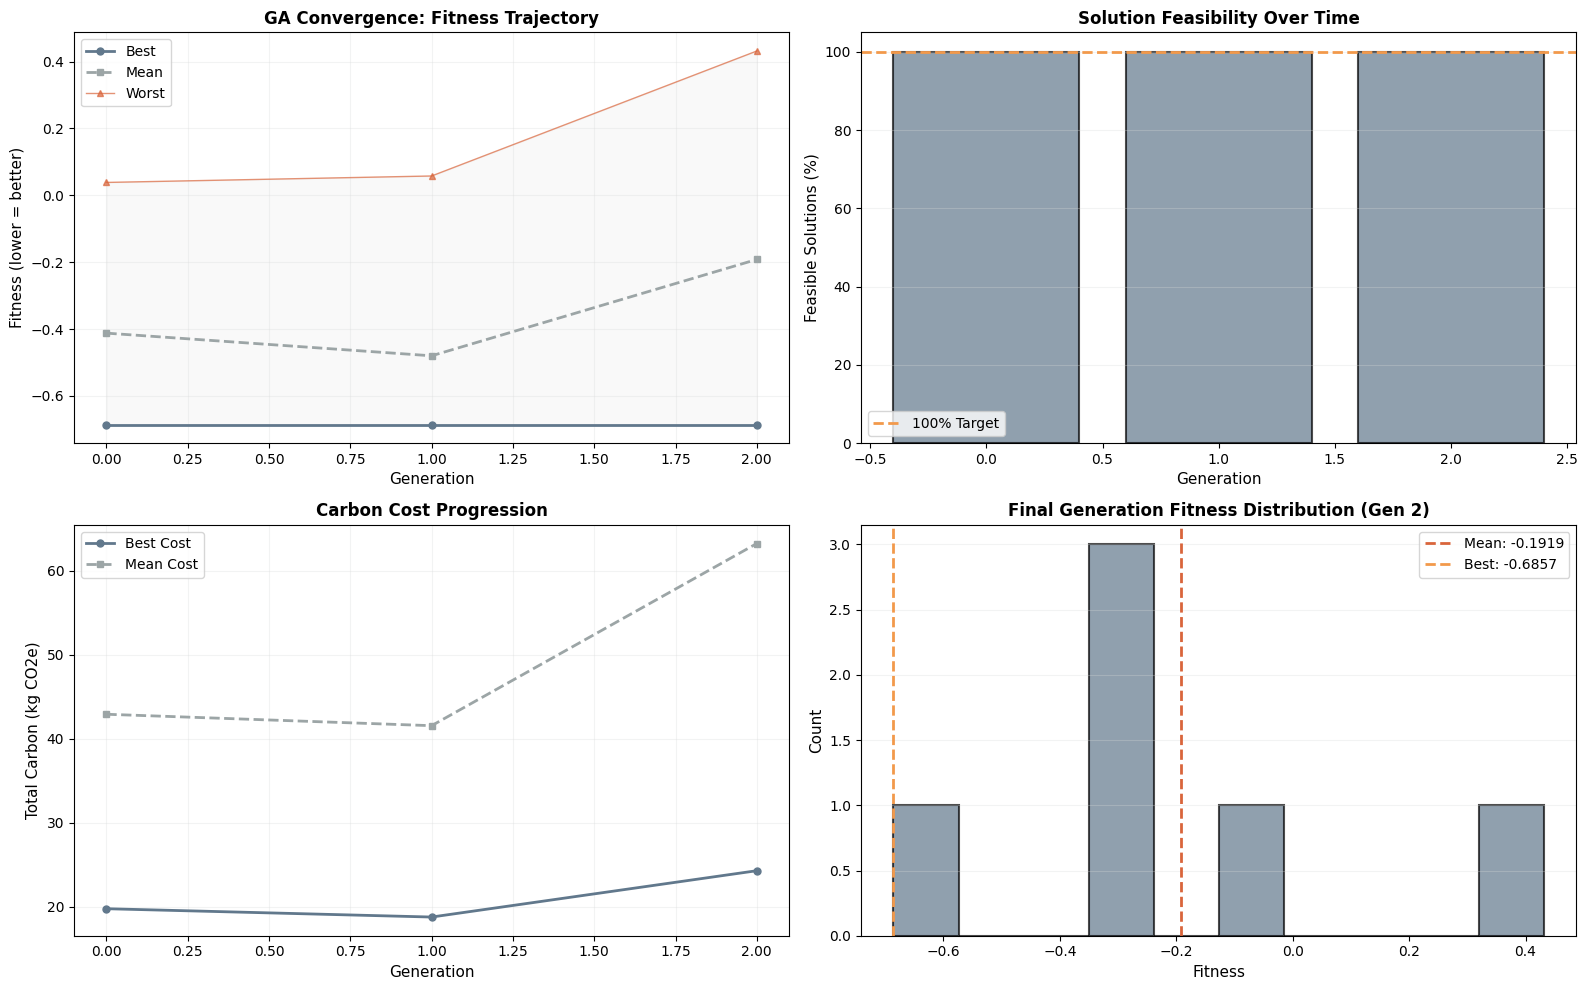

CONVERGENCE STATISTICS
            best_fit  worst_fit  mean_fit  std_fit  feasible_pct  best_cost  worst_cost  mean_cost
generation                                                                                        
0            -0.6857     0.0384   -0.4123   0.3355         100.0    19.7696     81.2988    42.9208
1            -0.6857     0.0577   -0.4801   0.2836         100.0    18.7778     94.8518    41.5608
2            -0.6857     0.4315   -0.1919   0.3691         100.0    24.2935    123.2959    63.2492

ANOMALY DETECTION & WARNINGS
HIGH DIVERSITY: Final population has high variance (|CV|=1.923), may not have converged
NO IMPROVEMENT: Best fitness did not improve from Gen 0 to final generation

ELITE INDIVIDUALS (TOP 10 RANKED DESIGNS)
 generation  individual   fitness status milp_status total_cost reuse_rate waste_total
          0           2 -0.685698     OK     Optimal      24.29      93.8%       0.512
          1           0 -0.685698     OK     Optimal      24.29      93

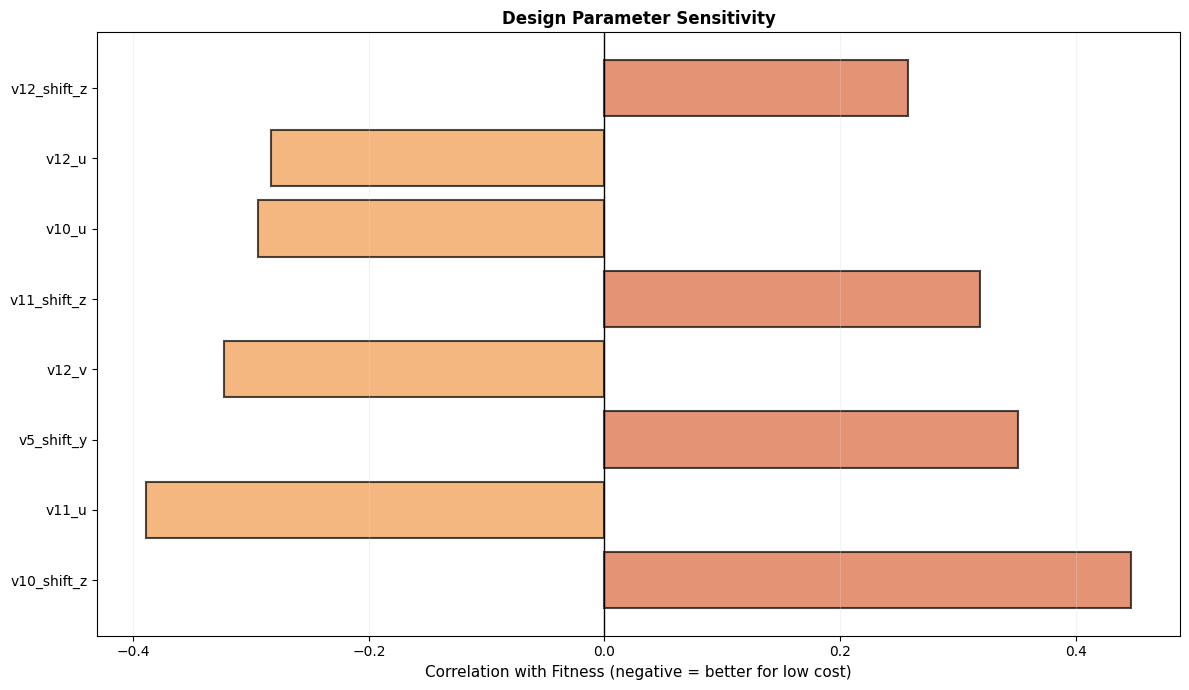


Analysis artifacts exported to: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\03_ga_data\ID20260426_231746_PS6_G3_E1_T2_CR0p85_MR0p25_MS0p10_UT1p25_SFMarea_length

ANALYSIS COMPLETE


In [13]:
import json
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Load centralized color theme
from config import PLOT_COLORS, PLOT_STYLE

# -----------------------------------------------------------------------------
# Analysis export directory (03_ga_data/<run_id>)
# -----------------------------------------------------------------------------
def _fmt_float_tag(x, ndigits=2):
    return f"{float(x):.{ndigits}f}".replace(".", "p")

ga_tag = (
    f"ID{datetime.now():%Y%m%d_%H%M%S}"
    f"_PS{int(GA_CONFIG['population_size'])}"
    f"_G{int(GA_CONFIG['generations'])}"
    f"_E{int(GA_CONFIG['elite_count'])}"
    f"_T{int(GA_CONFIG['tournament_k'])}"
    f"_CR{_fmt_float_tag(GA_CONFIG['crossover_rate'])}"
    f"_MR{_fmt_float_tag(GA_CONFIG['mutation_rate'])}"
    f"_MS{_fmt_float_tag(GA_CONFIG['mutation_scale'])}"
    f"_UT{_fmt_float_tag(GA_CONFIG['utilization_threshold'])}"
    f"_SFM{str(GA_CONFIG.get('surrogate_edge_feature_mode', 'na'))}"
)

GA_ANALYSIS_RUN_ID = ga_tag
GA_ANALYSIS_DIR = config.GA_DATA_PATH / GA_ANALYSIS_RUN_ID
GA_ANALYSIS_FIG_DIR = GA_ANALYSIS_DIR / "figures"
GA_ANALYSIS_TABLE_DIR = GA_ANALYSIS_DIR / "tables"
GA_ANALYSIS_META_DIR = GA_ANALYSIS_DIR / "meta"
GA_ANALYSIS_FIG_DIR.mkdir(parents=True, exist_ok=True)
GA_ANALYSIS_TABLE_DIR.mkdir(parents=True, exist_ok=True)
GA_ANALYSIS_META_DIR.mkdir(parents=True, exist_ok=True)

print(f"Analysis export run id: {GA_ANALYSIS_RUN_ID}")
print(f"Analysis export folder: {GA_ANALYSIS_DIR}")

# Split feasible vs all evaluations for robust diagnostics
ga_ok_df = ga_history_df[ga_history_df["status"] == "OK"].copy()
has_ok = len(ga_ok_df) > 0

# ============================================================================
# 1. CONVERGENCE ANALYSIS
# ============================================================================
gen_stats = ga_history_df.groupby("generation").agg({
    "fitness": ["min", "max", "mean", "std"],
    "status": lambda x: (x == "OK").sum() / len(x) * 100,
    "total_cost": ["min", "max", "mean"],
}).round(4)
gen_stats.columns = ["best_fit", "worst_fit", "mean_fit", "std_fit", "feasible_pct", "best_cost", "worst_cost", "mean_cost"]

fig, axes = plt.subplots(2, 2, figsize=PLOT_STYLE["figsize_large"])

# Convergence curve
ax = axes[0, 0]
ax.plot(gen_stats.index, gen_stats["best_fit"],
        color=PLOT_COLORS["primary"], linewidth=PLOT_STYLE["line_width"],
        label="Best", marker="o", markersize=PLOT_STYLE["marker_size"])
ax.plot(gen_stats.index, gen_stats["mean_fit"],
        color=PLOT_COLORS["secondary"], linewidth=PLOT_STYLE["line_width"],
        label="Mean", marker="s", markersize=PLOT_STYLE["marker_size"], linestyle="--")
ax.plot(gen_stats.index, gen_stats["worst_fit"],
        color=PLOT_COLORS["danger"], linewidth=1, alpha=0.7,
        label="Worst", marker="^", markersize=4)
ax.fill_between(gen_stats.index, gen_stats["best_fit"], gen_stats["worst_fit"],
                alpha=0.15, color=PLOT_COLORS["neutral"])
ax.set_xlabel("Generation", fontsize=11)
ax.set_ylabel("Fitness (lower = better)", fontsize=11)
ax.set_title("GA Convergence: Fitness Trajectory", fontsize=12, fontweight="bold")
ax.legend(loc="best")
ax.grid(True, alpha=PLOT_STYLE["grid_alpha"], color=PLOT_COLORS["neutral"])

# Feasibility rate
ax = axes[0, 1]
ax.bar(gen_stats.index, gen_stats["feasible_pct"],
       color=PLOT_COLORS["primary"], alpha=0.7, edgecolor=PLOT_COLORS["black"], linewidth=1.5)
ax.axhline(y=100, color=PLOT_COLORS["accent"], linestyle="--", linewidth=2, label="100% Target")
ax.set_xlabel("Generation", fontsize=11)
ax.set_ylabel("Feasible Solutions (%)", fontsize=11)
ax.set_title("Solution Feasibility Over Time", fontsize=12, fontweight="bold")
ax.set_ylim([0, 105])
ax.legend()
ax.grid(True, alpha=PLOT_STYLE["grid_alpha"], axis="y", color=PLOT_COLORS["neutral"])

# Cost trend
ax = axes[1, 0]
ax.plot(gen_stats.index, gen_stats["best_cost"],
        color=PLOT_COLORS["primary"], linewidth=PLOT_STYLE["line_width"],
        label="Best Cost", marker="o", markersize=PLOT_STYLE["marker_size"])
ax.plot(gen_stats.index, gen_stats["mean_cost"],
        color=PLOT_COLORS["secondary"], linewidth=PLOT_STYLE["line_width"],
        label="Mean Cost", marker="s", markersize=PLOT_STYLE["marker_size"], linestyle="--")
ax.set_xlabel("Generation", fontsize=11)
ax.set_ylabel("Total Carbon (kg CO2e)", fontsize=11)
ax.set_title("Carbon Cost Progression", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=PLOT_STYLE["grid_alpha"], color=PLOT_COLORS["neutral"])

# Fitness distribution (last generation)
ax = axes[1, 1]
last_gen_fitness = ga_history_df[ga_history_df["generation"] == ga_history_df["generation"].max()]["fitness"]
ax.hist(last_gen_fitness, bins=10, color=PLOT_COLORS["primary"], alpha=0.7,
        edgecolor=PLOT_COLORS["black"], linewidth=1.5)
ax.axvline(last_gen_fitness.mean(), color=PLOT_COLORS["danger"], linestyle="--",
           linewidth=2, label=f"Mean: {last_gen_fitness.mean():.4f}")
ax.axvline(last_gen_fitness.min(), color=PLOT_COLORS["accent"], linestyle="--",
           linewidth=2, label=f"Best: {last_gen_fitness.min():.4f}")
ax.set_xlabel("Fitness", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(f"Final Generation Fitness Distribution (Gen {ga_history_df['generation'].max()})",
             fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=PLOT_STYLE["grid_alpha"], axis="y", color=PLOT_COLORS["neutral"])

fig.savefig(GA_ANALYSIS_FIG_DIR / "01_convergence_dashboard.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

print("=" * 80)
print("CONVERGENCE STATISTICS")
print("=" * 80)
print(gen_stats.to_string())

# ============================================================================
# 2. ANOMALY DETECTION
# ============================================================================
print("\n" + "=" * 80)
print("ANOMALY DETECTION & WARNINGS")
print("=" * 80)

warnings_list = []

# Check for abrupt regressions in best fitness (delta-based, robust to negative values)
spike_threshold = 0.10
for gen in range(1, len(gen_stats)):
    prev_best = float(gen_stats.iloc[gen - 1]["best_fit"])
    curr_best = float(gen_stats.iloc[gen]["best_fit"])
    if (curr_best - prev_best) > spike_threshold:
        warnings_list.append(
            f"GEN {gen}: Best-fitness regression detected (delta={curr_best - prev_best:+.4f})"
        )

# Check for low-feasibility generations
all_infeasible_gens = gen_stats[gen_stats["feasible_pct"] < 50].index.tolist()
if all_infeasible_gens:
    warnings_list.append(f"INFEASIBILITY: Generations {all_infeasible_gens} had <50% feasible solutions")

# Check for stagnation (no improvement for multiple generations)
improvement_threshold = 0.0001
stagnant_gens = 0
for gen in range(1, len(gen_stats)):
    improvement = gen_stats.iloc[gen - 1]["best_fit"] - gen_stats.iloc[gen]["best_fit"]
    if improvement < improvement_threshold:
        stagnant_gens += 1
    else:
        stagnant_gens = 0
    if stagnant_gens >= 5:
        warnings_list.append(
            f"STAGNATION: No improvement in best fitness for 5+ generations (Gen {gen - 4} to {gen})"
        )
        break

# Check for high variance in last gen (population diversity)
last_gen_std = float(gen_stats.iloc[-1]["std_fit"])
last_gen_mean = float(gen_stats.iloc[-1]["mean_fit"])
cv = last_gen_std / max(abs(last_gen_mean), 1e-12)
if cv > 0.5:
    warnings_list.append(f"HIGH DIVERSITY: Final population has high variance (|CV|={cv:.3f}), may not have converged")

# Check for zero fitness improvement
if gen_stats.iloc[-1]["best_fit"] >= gen_stats.iloc[0]["best_fit"]:
    warnings_list.append("NO IMPROVEMENT: Best fitness did not improve from Gen 0 to final generation")

if not warnings_list:
    print("No anomalies detected. GA ran normally.")
else:
    for warn in warnings_list:
        print(warn)

# ============================================================================
# 3. ELITE PERFORMANCE
# ============================================================================
print("\n" + "=" * 80)
print("ELITE INDIVIDUALS (TOP 10 RANKED DESIGNS)")
print("=" * 80)
top_10 = ga_ranked_df.head(10)[["generation", "individual", "fitness", "status", "milp_status", "total_cost", "reuse_rate", "waste_total"]].copy()
top_10["reuse_rate"] = top_10["reuse_rate"].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else "N/A")
top_10["total_cost"] = top_10["total_cost"].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "N/A")
top_10["waste_total"] = top_10["waste_total"].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "N/A")
top_10["fitness"] = top_10["fitness"].apply(lambda x: f"{x:.6f}")
print(top_10.to_string(index=False))

# ============================================================================
# 4. FEASIBILITY BREAKDOWN
# ============================================================================
print("\n" + "=" * 80)
print("SOLUTION STATUS BREAKDOWN")
print("=" * 80)
status_counts = ga_history_df["status"].value_counts()
print(f"Total individuals evaluated: {len(ga_history_df)}")
for status, count in status_counts.items():
    pct = (count / len(ga_history_df)) * 100
    print(f"  {status}: {count} ({pct:.1f}%)")

# MILP status breakdown (for feasible only)
milp_breakdown = ga_history_df[ga_history_df["status"] == "OK"]["milp_status"].value_counts()
if not milp_breakdown.empty:
    print("\nMILP Solution Status (OK individuals only):")
    for status, count in milp_breakdown.items():
        pct = (count / len(ga_history_df[ga_history_df["status"] == "OK"])) * 100
        print(f"  {status}: {count} ({pct:.1f}%)")

# ============================================================================
# 5. PARAMETER CORRELATION ANALYSIS (feasible designs only)
# ============================================================================
print("\n" + "=" * 80)
print("PARAMETER SENSITIVITY: Correlation with Fitness")
print("=" * 80)

# Extract design params and fitness from feasible rows only
design_param_rows = []
for _, row in ga_ok_df.iterrows():
    try:
        params = json.loads(row["design_params_json"])
        params["fitness"] = row["fitness"]
        design_param_rows.append(params)
    except Exception:
        pass

print(f"Using {len(design_param_rows)} feasible designs for sensitivity analysis.")

correlations_sorted = []
if design_param_rows:
    df_params = pd.DataFrame(design_param_rows)

    # Calculate correlations
    numeric_cols = df_params.select_dtypes(include=[np.number]).columns.tolist()
    if "fitness" in numeric_cols:
        numeric_cols.remove("fitness")

    correlations = {}
    for col in numeric_cols:
        corr = df_params[col].corr(df_params["fitness"])
        if pd.notna(corr):
            correlations[col] = corr

    # Sort by absolute correlation
    correlations_sorted = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

    print("\nTop parameters correlated with fitness (negative = lower fitness when param increases):")
    for param, corr in correlations_sorted[:8]:
        direction = "up helps" if corr < 0 else "down hurts"
        print(f"  {param:20s}: {corr:+.4f}  ({direction})")

    # Correlation bar chart
    if len(correlations_sorted) >= 3:
        fig_corr, ax = plt.subplots(figsize=PLOT_STYLE["figsize_medium"])
        top_params = [x[0] for x in correlations_sorted[:8]]
        corr_values = [x[1] for x in correlations_sorted[:8]]
        colors = [PLOT_COLORS["accent"] if c < 0 else PLOT_COLORS["danger"] for c in corr_values]
        ax.barh(range(len(top_params)), corr_values, color=colors, alpha=0.7,
                edgecolor=PLOT_COLORS["black"], linewidth=1.5)
        ax.set_yticks(range(len(top_params)))
        ax.set_yticklabels(top_params)
        ax.set_xlabel("Correlation with Fitness (negative = better for low cost)", fontsize=11)
        ax.set_title("Design Parameter Sensitivity", fontsize=12, fontweight="bold")
        ax.axvline(x=0, color=PLOT_COLORS["black"], linewidth=1.0)
        ax.grid(True, alpha=PLOT_STYLE["grid_alpha"], axis="x", color=PLOT_COLORS["neutral"])
        fig_corr.savefig(GA_ANALYSIS_FIG_DIR / "02_parameter_sensitivity.png", dpi=300, bbox_inches="tight")
        plt.tight_layout()
        plt.show()
else:
    print("Could not extract feasible design parameters for correlation analysis.")

# -----------------------------------------------------------------------------
# Save analysis data artifacts
# -----------------------------------------------------------------------------
gen_stats.to_csv(GA_ANALYSIS_TABLE_DIR / "gen_stats.csv")
last_gen_fitness.to_frame(name="fitness").to_csv(GA_ANALYSIS_TABLE_DIR / "last_generation_fitness.csv", index=False)
top_10.to_csv(GA_ANALYSIS_TABLE_DIR / "top_10_ranked_designs.csv", index=False)
status_counts.rename("count").to_csv(GA_ANALYSIS_TABLE_DIR / "status_counts.csv")
if not milp_breakdown.empty:
    milp_breakdown.rename("count").to_csv(GA_ANALYSIS_TABLE_DIR / "milp_status_breakdown_ok.csv")
if design_param_rows:
    pd.DataFrame(design_param_rows).to_csv(GA_ANALYSIS_TABLE_DIR / "design_params_feasible.csv", index=False)
if correlations_sorted:
    pd.DataFrame(correlations_sorted, columns=["parameter", "correlation"]).to_csv(
        GA_ANALYSIS_TABLE_DIR / "parameter_correlations.csv", index=False
    )

analysis_meta = {
    "run_id": GA_ANALYSIS_RUN_ID,
    "analysis_export_dir": str(GA_ANALYSIS_DIR),
    "total_evaluations": int(len(ga_history_df)),
    "feasible_evaluations": int(len(ga_ok_df)),
    "warnings": warnings_list,
}
with open(GA_ANALYSIS_META_DIR / "analysis_meta.json", "w", encoding="utf-8") as f:
    json.dump(analysis_meta, f, indent=2)

print(f"\nAnalysis artifacts exported to: {GA_ANALYSIS_DIR}")
print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)


In [16]:
# ============================================================================
# EXTENDED DIAGNOSTICS: Multi-Criteria Analysis
# ============================================================================

print("\n" + "=" * 80)
print("MULTI-CRITERIA TRADE-OFF ANALYSIS")
print("=" * 80)

# Restrict ranking to feasible designs only
diagnostic_source = ga_ranked_df[ga_ranked_df["status"] == "OK"].copy()
if diagnostic_source.empty:
    diagnostic_source = ga_ranked_df.copy()
    print("Warning: no feasible designs found, using all designs for diagnostic ranking.")

# Create multi-objective ranking
diagnostic_df = diagnostic_source.head(30).copy()
diagnostic_df["cost_rank"] = diagnostic_df["total_cost"].rank()
diagnostic_df["reuse_rank"] = diagnostic_df["reuse_rate"].rank(ascending=False)
diagnostic_df["waste_rank"] = diagnostic_df["waste_total"].rank()
diagnostic_df["fitness_rank"] = diagnostic_df["fitness"].rank()
diagnostic_df["overall_score"] = (
    diagnostic_df["cost_rank"] +
    diagnostic_df["reuse_rank"] +
    diagnostic_df["waste_rank"]
) / 3

print("\nTop designs by different criteria:")
print("\n1. LOWEST EMBODIED CARBON:")
cost_winners = diagnostic_df.nsmallest(3, "total_cost")[["generation", "individual", "fitness", "total_cost", "reuse_rate", "waste_total"]]
print(cost_winners.to_string(index=False))

print("\n2. HIGHEST REUSE RATE:")
reuse_winners = diagnostic_df.nlargest(3, "reuse_rate")[["generation", "individual", "fitness", "total_cost", "reuse_rate", "waste_total"]]
print(reuse_winners.to_string(index=False))

print("\n3. LOWEST WASTE VOLUME:")
waste_winners = diagnostic_df.nsmallest(3, "waste_total")[["generation", "individual", "fitness", "total_cost", "reuse_rate", "waste_total"]]
print(waste_winners.to_string(index=False))

print("\n4. OVERALL BEST (multi-criteria balanced):")
overall_winners = diagnostic_df.nsmallest(3, "overall_score")[["generation", "individual", "fitness", "total_cost", "reuse_rate", "waste_total", "overall_score"]]
print(overall_winners.to_string(index=False))

# ============================================================================
# GENERATION-BY-GENERATION DETAILED STATS
# ============================================================================
print("\n" + "=" * 80)
print("GENERATION-BY-GENERATION PERFORMANCE DETAIL")
print("=" * 80)

gen_detail = ga_history_df.groupby("generation").agg({
    "fitness": ["count", "min", "mean", "max", lambda x: (x < 1e6).sum()],
    "total_cost": ["min", "mean", "max"],
    "reuse_rate": ["min", "mean", "max"],
}).round(3)

gen_detail.columns = ["n_eval", "best_fit", "mean_fit", "worst_fit", "n_feasible",
                       "best_cost", "mean_cost", "worst_cost",
                       "min_reuse%", "mean_reuse%", "max_reuse%"]

print(gen_detail.to_string())

# ============================================================================
# SEARCH SPACE EXPLORATION CHECK
# ============================================================================
print("\n" + "=" * 80)
print("SEARCH SPACE EXPLORATION ASSESSMENT")
print("=" * 80)

if design_param_rows:
    df_params = pd.DataFrame(design_param_rows)
    numeric_cols = df_params.select_dtypes(include=[np.number]).columns.tolist()
    if "fitness" in numeric_cols:
        numeric_cols.remove("fitness")

    print(f"\nDesign parameters explored across {len(design_param_rows)} feasible individuals:\n")
    for col in numeric_cols[:8]:  # Show top 8 params
        if col in df_params.columns:
            min_val = df_params[col].min()
            max_val = df_params[col].max()

            # Check if we're using full search space
            if col in optimizer_search_space:
                space = optimizer_search_space[col]
                if space["type"] == "continuous":
                    space_min = space["min"]
                    space_max = space["max"]
                    space_range = space_max - space_min
                    explored_pct = ((max_val - min_val) / space_range * 100) if space_range > 0 else 0

                    print(f"{col:20s}: [{min_val:+.4f}, {max_val:+.4f}] (range: {max_val-min_val:+.4f}) - {explored_pct:.1f}% of search space")
                else:
                    unique_vals = df_params[col].nunique()
                    print(f"{col:20s}: {unique_vals} unique values (discrete)")
            else:
                print(f"{col:20s}: [{min_val:+.4f}, {max_val:+.4f}]")
else:
    print("No feasible design-parameter rows available for exploration assessment.")

# ============================================================================
# FAILURE/ERROR ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("FAILURE ANALYSIS")
print("=" * 80)

penalized = ga_history_df[ga_history_df["status"] == "PENALIZED"]
if len(penalized) > 0:
    print(f"\nPenalized individuals: {len(penalized)} ({len(penalized)/len(ga_history_df)*100:.1f}%)")

    # Reason breakdown
    error_reasons = penalized["reason"].value_counts().head(5)
    print("\nTop failure reasons:")
    for reason, count in error_reasons.items():
        print(f"  - {str(reason)[:80]:80s}: {count} times")

    # Which generations had the most failures?
    failures_by_gen = penalized["generation"].value_counts().sort_index()
    print("\nFailures by generation:")
    for gen, count in failures_by_gen.items():
        pct = (count / len(ga_history_df[ga_history_df["generation"] == gen])) * 100
        print(f"  Gen {gen:2d}: {count:2d} failures ({pct:5.1f}%)")
else:
    error_reasons = pd.Series(dtype="int64")
    failures_by_gen = pd.Series(dtype="int64")
    print("No penalized individuals. All solutions converged to feasible MILP states.")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

total_evals = len(ga_history_df)
total_feasible = len(ga_history_df[ga_history_df["status"] == "OK"])
success_rate = (total_feasible / total_evals) * 100
best_fitness = ga_ranked_df.iloc[0]["fitness"]
best_cost = ga_ranked_df.iloc[0]["total_cost"]
best_reuse = ga_ranked_df.iloc[0]["reuse_rate"]

print(f"\nGA Execution Summary:")
print(f"  Generations run:       {ga_history_df['generation'].max() + 1}")
print(f"  Population size:       {GA_CONFIG['population_size']}")
print(f"  Total individuals:     {total_evals}")
print(f"  Feasible solutions:    {total_feasible}/{total_evals} ({success_rate:.1f}%)")
print(f"\nBest Design Found:")
print(f"  Fitness score:         {best_fitness:.6f}")
print(f"  Carbon cost:           {best_cost:.2f} kg CO2e")
print(f"  Reclaimed timber:      {best_reuse:.1f}%")
print(f"  Found in generation:   {ga_ranked_df.iloc[0]['generation']}")
print("\nOptimizer Status: COMPLETE AND READY FOR EXPORT")

# -----------------------------------------------------------------------------
# Save extended diagnostics artifacts
# -----------------------------------------------------------------------------
diagnostic_df.to_csv(GA_ANALYSIS_TABLE_DIR / "diagnostic_df_top30.csv", index=False)
diagnostic_source.to_csv(GA_ANALYSIS_TABLE_DIR / "multi_criteria_source_all_feasible.csv", index=False)

# Explicit multi-criteria exports
multi_criteria_cols = [
    "generation",
    "individual",
    "fitness",
    "total_cost",
    "reuse_rate",
    "waste_total",
    "cost_rank",
    "reuse_rank",
    "waste_rank",
    "fitness_rank",
    "overall_score",
]
diagnostic_df[multi_criteria_cols].to_csv(
    GA_ANALYSIS_TABLE_DIR / "multi_criteria_tradeoff_top30.csv", index=False
)

diagnostic_df.nsmallest(len(diagnostic_df), "overall_score")[multi_criteria_cols].to_csv(
    GA_ANALYSIS_TABLE_DIR / "multi_criteria_tradeoff_sorted.csv", index=False
)

cost_winners.to_csv(GA_ANALYSIS_TABLE_DIR / "winners_lowest_carbon.csv", index=False)
reuse_winners.to_csv(GA_ANALYSIS_TABLE_DIR / "winners_highest_reuse.csv", index=False)
waste_winners.to_csv(GA_ANALYSIS_TABLE_DIR / "winners_lowest_waste.csv", index=False)
overall_winners.to_csv(GA_ANALYSIS_TABLE_DIR / "winners_overall_balanced.csv", index=False)

gen_detail.to_csv(GA_ANALYSIS_TABLE_DIR / "generation_detail.csv")
if len(error_reasons) > 0:
    error_reasons.rename("count").to_csv(GA_ANALYSIS_TABLE_DIR / "error_reasons_top5.csv")
if len(failures_by_gen) > 0:
    failures_by_gen.rename("count").to_csv(GA_ANALYSIS_TABLE_DIR / "failures_by_generation.csv")

final_summary = {
    "run_id": GA_ANALYSIS_RUN_ID,
    "analysis_export_dir": str(GA_ANALYSIS_DIR),
    "generations_run": int(ga_history_df["generation"].max() + 1),
    "population_size": int(GA_CONFIG["population_size"]),
    "total_individuals": int(total_evals),
    "feasible_solutions": int(total_feasible),
    "success_rate_percent": float(success_rate),
    "best_fitness": float(best_fitness),
    "best_cost": float(best_cost),
    "best_reuse": float(best_reuse),
    "best_found_generation": int(ga_ranked_df.iloc[0]["generation"]),
}
with open(GA_ANALYSIS_META_DIR / "final_summary.json", "w", encoding="utf-8") as f:
    json.dump(final_summary, f, indent=2)

print(f"\nExtended diagnostics exported to: {GA_ANALYSIS_DIR}")



MULTI-CRITERIA TRADE-OFF ANALYSIS

Top designs by different criteria:

1. LOWEST EMBODIED CARBON:
 generation  individual   fitness  total_cost  reuse_rate  waste_total
          1           5 -0.658846   18.777826      81.250     0.688845
          0           0 -0.572862   19.769592      75.000     0.698473
          1           1 -0.632785   24.097516      84.375     0.673168

2. HIGHEST REUSE RATE:
 generation  individual   fitness  total_cost  reuse_rate  waste_total
          0           2 -0.685698   24.293467       93.75     0.511686
          1           0 -0.685698   24.293467       93.75     0.511686
          2           0 -0.685698   24.293467       93.75     0.511686

3. LOWEST WASTE VOLUME:
 generation  individual   fitness  total_cost  reuse_rate  waste_total
          0           4 -0.666065   28.167466       87.50     0.502225
          0           2 -0.685698   24.293467       93.75     0.511686
          1           0 -0.685698   24.293467       93.75     0.511686


# EXPORT

In [17]:
# Export GA history and best candidate payload
import shutil

ga_history_path = config.GA_DATA_PATH / "c23_ga_history.csv"
ga_ranked_path = config.GA_DATA_PATH / "c23_ga_ranked.csv"
ga_best_design_path = config.GA_DATA_PATH / "c23_ga_best_design.json"

ga_history_df.to_csv(ga_history_path, index=False)
ga_ranked_df.to_csv(ga_ranked_path, index=False)

analysis_export_dir = str(globals().get("GA_ANALYSIS_DIR", ""))
analysis_run_id = str(globals().get("GA_ANALYSIS_RUN_ID", ""))

# Fallback if analysis cell was not run in this kernel session
if not analysis_export_dir:
    fallback_id = f"ID{__import__('datetime').datetime.now():%Y%m%d_%H%M%S}_EXPORT_ONLY"
    GA_ANALYSIS_RUN_ID = fallback_id
    GA_ANALYSIS_DIR = config.GA_DATA_PATH / fallback_id
    GA_ANALYSIS_FIG_DIR = GA_ANALYSIS_DIR / "figures"
    GA_ANALYSIS_TABLE_DIR = GA_ANALYSIS_DIR / "tables"
    GA_ANALYSIS_META_DIR = GA_ANALYSIS_DIR / "meta"
    GA_ANALYSIS_FIG_DIR.mkdir(parents=True, exist_ok=True)
    GA_ANALYSIS_TABLE_DIR.mkdir(parents=True, exist_ok=True)
    GA_ANALYSIS_META_DIR.mkdir(parents=True, exist_ok=True)
    analysis_export_dir = str(GA_ANALYSIS_DIR)
    analysis_run_id = GA_ANALYSIS_RUN_ID

best_payload = {
    "fitness": float(best_overall["fitness"]),
    "status": best_overall["status"],
    "milp_status": best_overall.get("milp_status"),
    "total_cost": float(best_overall.get("total_cost", float("inf"))),
    "reuse_rate": float(best_overall.get("reuse_rate", 0.0)),
    "waste_total": float(best_overall.get("waste_total", float("inf"))),
    "design_params": best_overall["design_params"],
    "normalization_constants": FIXED_NORMALIZATION_CONSTANTS,
    "ga_config": GA_CONFIG,
    "analysis_run_id": analysis_run_id,
    "analysis_export_dir": analysis_export_dir,
}

with open(ga_best_design_path, "w", encoding="utf-8") as f:
    json.dump(best_payload, f, indent=2)

# Also copy core c23 exports into the run-specific analysis folder
analysis_dir_path = Path(analysis_export_dir)
analysis_dir_path.mkdir(parents=True, exist_ok=True)

c23_history_in_run = analysis_dir_path / "c23_ga_history.csv"
c23_ranked_in_run = analysis_dir_path / "c23_ga_ranked.csv"
c23_best_in_run = analysis_dir_path / "c23_ga_best_design.json"

shutil.copy2(ga_history_path, c23_history_in_run)
shutil.copy2(ga_ranked_path, c23_ranked_in_run)
shutil.copy2(ga_best_design_path, c23_best_in_run)

print(f"GA history exported: {ga_history_path}")
print(f"GA ranked table exported: {ga_ranked_path}")
print(f"Best design exported: {ga_best_design_path}")
print(f"Analysis folder exported: {analysis_export_dir}")
print(f"Copied to run folder: {c23_history_in_run}")
print(f"Copied to run folder: {c23_ranked_in_run}")
print(f"Copied to run folder: {c23_best_in_run}")

display(pd.DataFrame([best_payload]).drop(columns=["design_params", "ga_config"]))


GA history exported: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\03_ga_data\c23_ga_history.csv
GA ranked table exported: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\03_ga_data\c23_ga_ranked.csv
Best design exported: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\03_ga_data\c23_ga_best_design.json
Analysis folder exported: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\03_ga_data\ID20260426_231746_PS6_G3_E1_T2_CR0p85_MR0p25_MS0p10_UT1p25_SFMarea_length
Copied to run folder: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\03_ga_data\ID20260426_231746_PS6_G3_E1_T2_CR0p85_MR0p25_MS0p10_UT1p25_SFMarea_length\c23_ga_history.csv
Copied to run folder: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\03_ga_data\ID20260426_231746_PS6_G3_E1_T2_CR0p85_MR0p25_MS0p10_UT1p25_SFMarea_length\c23_ga_

,fitness,status,milp_status,total_cost,reuse_rate,waste_total,normalization_constants,analysis_run_id,analysis_export_dir
0,-0.685698,OK,Optimal,24.293467,93.75,0.511686,"{'C_max': 169.90549350124616, 'R_max': 81.25, ...",ID20260426_231746_PS6_G3_E1_T2_CR0p85_MR0p25_M...,C:\Users\Jasper\OneDrive\06 Building Technolog...
